In [1]:
import sys

sys.path.append("/home/hpc/v120bb/v120bb18/UnReflectAnything")
import torch

print(torch.cuda.is_available())


True


In [2]:
from dataset.rgbp import SCARED_Dataset,CROMO_Dataset
from utilities import panelize, rgb
from polar_highlighter import PolarHighlighter

ph = PolarHighlighter(height=448, width=448).cuda()

%load_ext autoreload
%autoreload 2    

DATASET  [21:25:41] Processing 4 datasets: ['SCRREAM', 'HOUSECAT6D', 'POLARGB', 'CROMO']

DATASET  [21:25:41] Using all scenes except VAL_SCENES for SCRREAM training

DATASET  [21:25:41]   ✓ Created training dataset for SCRREAM: 14770 samples (excluding 2 val scenes)

DATASET  [21:25:41]   ✓ Created validation dataset for SCRREAM: 1667 samples from 2 scenes

DATASET  [21:25:41] Using all scenes except VAL_SCENES for HOUSECAT6D training

...

DATASET  [21:25:41] === Dataset Creation Summary ===

DATASET  [21:25:41] Training:   44641 total samples

DATASET  [21:25:41] Validation: 3258 total samples

DATASET  [21:25:41] Test:       3258 total samples

dict_keys(['I0', 'I45', 'I90', 'I135', 'S0', 'S1', 'S2', 'S3', 'stokes', 'intensity', 'DoLP', 'AoP', 'AoLP', 'DoP', 'DoCP', 'ellipticity_angle', 'f_spec', 'rgb', 'specular', 'diffuse', 'intrinsics'])


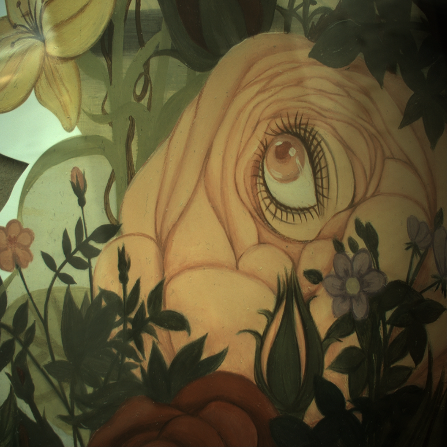

In [3]:
from main import load_and_process_config
from dataset import from_config
config = load_and_process_config("config_train.yaml")
dataset = from_config(config)["training"]

# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)
idataloade = iter(dataloader)
# Test loading a batch
for b, batch in enumerate(dataloader):
    image = batch["rgb"].cuda()
    break
print(batch.keys())
rgb(
    batch["rgb"][0],
    as_tensor=False,
    # label={"position": "top-left", "height": 40, "margin": 4, "text": "RGB"},
)


In [4]:
from models import RGBPOLDecomposer
from main import create_model_from_config
model = create_model_from_config(config,torch.device("cuda"))


MODEL    [21:25:46] Model with class RGBPOLDecomposer created with 182,679,591 parameters

In [5]:
batch_gpu = {k: v.cuda() for k, v in batch.items()}
decomp = model(batch_gpu)

In [16]:
decomp.keys()

dict_keys(['diffuse', 'highlight'])

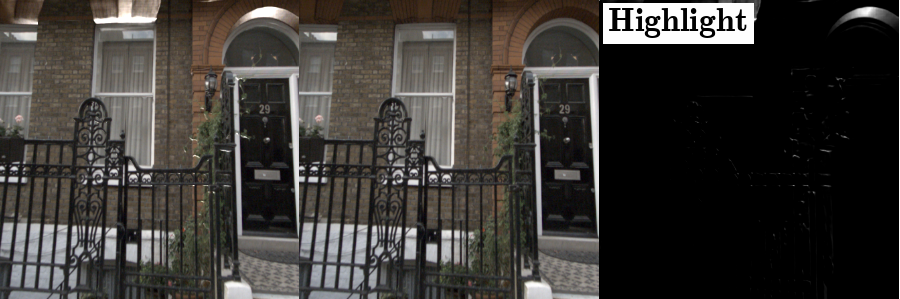

In [12]:

# pol = torch.cat([batch["S0"], batch["S1"], batch["S2"]], dim=1).cuda()
intrinsic = batch["intrinsics"].cuda()
intrinsic_res = intrinsic.clone()
intrinsic_res[0, 0, 0] = intrinsic[0, 0, 0] * 448 / 1140
intrinsic_res[0, 1, 1] = intrinsic[0, 1, 1] * 448 / 892
intrinsic_res[0, 0, 2] = intrinsic[0, 0, 2] * 448 / 1140
intrinsic_res[0, 1, 2] = intrinsic[0, 1, 2] * 448 / 892


result = ph(
    rgb=image,
    intrinsic=intrinsic_res,
    shininess=4,
    ks=1.5,
)
rgb(
    panelize(
        rgb(
            result["rgb_highlighted"][0],
            resize=(300, 300),
            as_tensor=True,
            # label={"position": "top-left", "height": 40, "margin": 4, "text": "Composition"},
            
        ),
        rgb(
            batch["rgb"][0],
            resize=(300, 300),
            as_tensor=True,
            # label={"position": "top-left", "height": 40, "margin": 4, "text": "RGB"},
        ),
        rgb(
            result["highlight"][0],
            resize=(300, 300),
            as_tensor=True,
            colormap="gray",
            label={"position": "top-left", "height": 40, "margin": 4, "text": "Highlight"},
            
        ),
    )
)
# break

In [5]:
from dataset import from_config
from main import load_and_process_config

config = load_and_process_config("config_train.yaml")
dataset = from_config(config)["training"]

DATASET  [11:41:47] Processing 1 datasets: ['CROMO']

DATASET  [11:41:47] Using dataset-specific TRAIN_SCENES for CROMO: kitchen

DATASET  [11:41:47]   ✓ Created training dataset for CROMO: 3030 samples from specific scenes

DATASET  [11:41:47]   ! No validation scenes specified for CROMO

DATASET  [11:41:47] === Dataset Creation Summary ===

DATASET  [11:41:47] Training:   3030 total samples

DATASET  [11:41:47] Validation: 0 total samples

DATASET  [11:41:47] Test:       0 total samples

In [ ]:
# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    break
image = batch["rgb"]

rgb(
    panelize(
        rgb(
            batch["rgb"],
            as_tensor=False,
            border={"color": "#000000", "thickness": 1},
            # colormap="jet",
            label={"position": "top-left", "height": 80, "margin": 20, "text": "RGB"},
        ),
        rgb(
            batch["diffuse"],
            as_tensor=True,
            border={"color": "#000000", "thickness": 1},
            # colormap="jet",
            label={
                "position": "top-left",
                "height": 80,
                "margin": 20,
                "text": "I-Diffuse",
            },
        ),
        rgb(
            batch["specular"],
            as_tensor=True,
            border={"color": "#000000", "thickness": 1},
            # colormap="jet",
            label={
                "position": "top-left",
                "height": 80,
                "margin": 20,
                "text": "I-Specular",
            },
        ),
        mode="horizontal",
    )
)

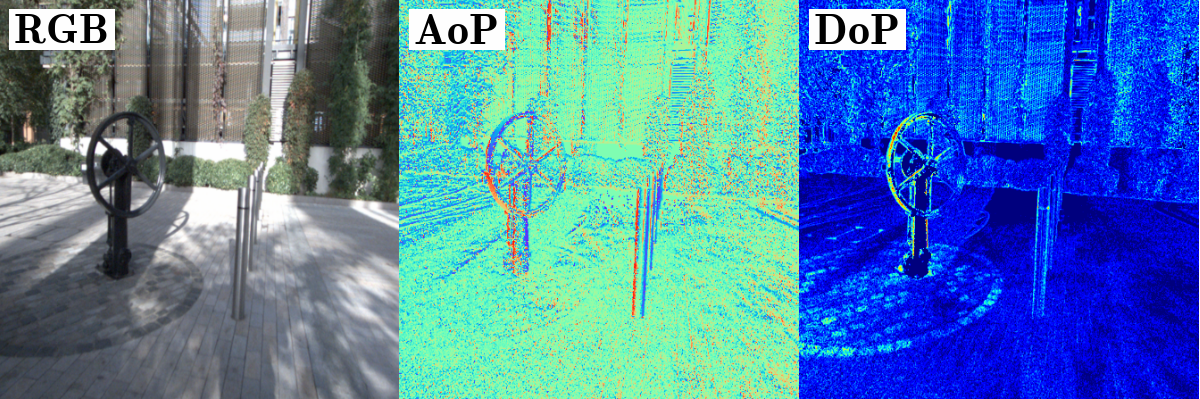

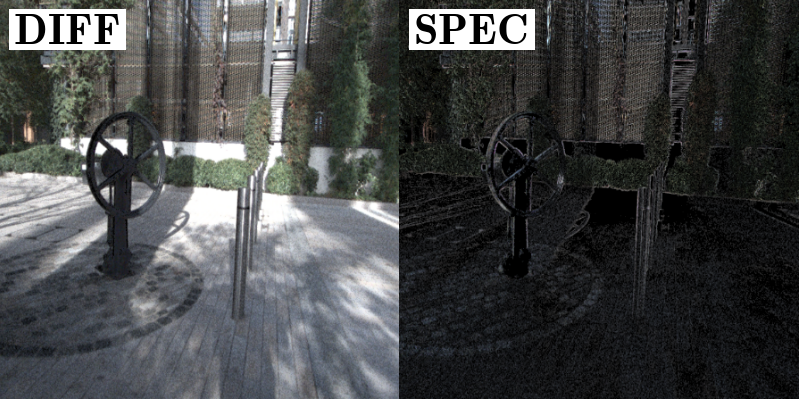

In [ ]:
# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    break

rgb(
    panelize(
        rgb(
        batch["rgb"],
        as_tensor=True,
        resize=(400,400),
        # border={"color": "#000000", "thickness": 1},
        label={"position": "top-left", "height": 40, "margin": 10, "text": "RGB"},
        ),
        rgb(
            -batch["AoP"],
            as_tensor=True,
            resize=(400,400),
            # border={"color": "#00000", "thickness": 1},
            colormap="rainbow",
            label={
                "position": "top-left",
                "height": 40,
                "margin": 10,
                "text": "AoP",
                "style": "normal",
            },
        ),
        rgb(
            batch["DoP"],
            as_tensor=True,
            resize=(400,400),
            # border={"color": "#00000", "thickness": 1},
            colormap="jet",
            label={"position": "top-left", "height": 40, "margin": 10, "text": "DoP"},
        ),
        mode="horizontal",
    )
)
rgb(
    panelize(
        rgb(
            batch["diffuse"],
            as_tensor=True,
            resize=(400,400),
            # border={"color": "#000000", "thickness": 1},
            # colormap="jet",
            label={"position": "top-left", "height": 40, "margin": 10, "text": "DIFF"},
        ),
        rgb(
            batch["specular"],
            as_tensor=True,
            resize=(400,400),
            # border={"color": "#000000", "thickness": 1},
            # colormap="jet",
            label={"position": "top-left", "height": 40, "margin": 10, "text": "SPEC"},
        ),
        mode="horizontal",
    )
)

In [ ]:
rgb(
    batch["rgb"],
    as_tensor=False,
    border={"color": "#000000", "thickness": 1},
    # colormap="jet",
    label={"position": "top-left", "height": 80, "margin": 20, "text": "RGB"},
)

In [ ]:
rgb(
    panelize(
        rgb(
            batch["I0"],
            as_tensor=True,
            border={"color": "#01CBCA", "thickness": 20},
            label={"position": "top-left", "height": 80, "margin": 20, "text": "I0"},
        ),
        rgb(
            batch["I45"],
            as_tensor=True,
            border={"color": "#F18222", "thickness": 20},
            label={"position": "top-left", "height": 80, "margin": 20, "text": "I45"},
        ),
        rgb(
            batch["I90"],
            as_tensor=True,
            border={"color": "#1B98FD", "thickness": 20},
            label={"position": "top-left", "height": 80, "margin": 20, "text": "I90"},
        ),
        rgb(
            batch["I135"],
            as_tensor=True,
            border={"color": "#01FEFE", "thickness": 20},
            label={"position": "top-left", "height": 80, "margin": 20, "text": "I135"},
        ),
        mode="horizontal",
    )
)
# rgb(
#     panelize(
#         rgb(batch["S0"], resize=(448, 448), as_tensor=True, colormap="gray"),
#         rgb(batch["S1"], resize=(448, 448), as_tensor=True, colormap="gray"),
#         rgb(batch["S2"], resize=(448, 448), as_tensor=True, colormap="gray"),
#     )
# )

In [ ]:
batch["S1"].min(), batch["S1"].max()

In [ ]:
rgb(
    panelize(
        rgb(
            batch["S0"],
            as_tensor=True,
            border={"color": "#000000", "thickness": 1},
            colormap="jet",
            label={
                "position": "top-left",
                "height": 80,
                "margin": 20,
                "text": "S0",
                "style": "normal",
            },
        ),
        rgb(
            batch["S1"],
            as_tensor=True,
            border={"color": "#000000", "thickness": 1},
            colormap="jet",
            label={"position": "top-left", "height": 80, "margin": 20, "text": "S1"},
        ),
        rgb(
            batch["S2"],
            as_tensor=True,
            border={"color": "#000000", "thickness": 1},
            colormap="jet",
            label={"position": "top-left", "height": 80, "margin": 20, "text": "S2"},
        ),
        mode="horizontal",
    )
)

In [ ]:
rgb(
    panelize(
        rgb(
            -batch["AoP"],
            as_tensor=True,
            border={"color": "#00000", "thickness": 1},
            colormap="rainbow",
            label={
                "position": "top-left",
                "height": 80,
                "margin": 20,
                "text": "AoP",
                "style": "normal",
            },
        ),
        rgb(
            batch["DoP"],
            as_tensor=True,
            border={"color": "#00000", "thickness": 1},
            colormap="jet",
            label={"position": "top-left", "height": 80, "margin": 20, "text": "DoP"},
        ),
        mode="horizontal",
    )
)

In [ ]:
rgb(
    panelize(
        rgb(
            batch["f_spec"],
            as_tensor=True,
            border={"color": "#000000", "thickness": 1},
            colormap="gray",
            label={
                "position": "top-left",
                "height": 80,
                "margin": 20,
                "text": "S0",
                "style": "normal",
            },
        ),
        rgb(
            batch["diffuse"],
            as_tensor=True,
            border={"color": "#000000", "thickness": 1},
            # colormap="jet",
            label={"position": "top-left", "height": 80, "margin": 20, "text": "S1"},
        ),
        rgb(
            batch["specular"],
            as_tensor=True,
            border={"color": "#000000", "thickness": 1},
            # colormap="jet",
            label={"position": "top-left", "height": 80, "margin": 20, "text": "S2"},
        ),
        mode="vertical",
    )
)

In [ ]:
from polar_highlighter import PolarHighlighter

ph = PolarHighlighter(height=448, width=448).cuda()


In [ ]:
light_pos = torch.tensor([[4.4347, 9.7698, 0.0731]], device="cuda:0")
rgbh = []
rgbhh = []
shininesses = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
kses = [1, 1.5, 2]
for shininess in shininesses:
    for ks in kses:
        result = ph(
            rgb=image.cuda(),
            intrinsic=batch["intrinsics"].cuda(),
            shininess=shininess,
            light_pos=light_pos,
            ks=ks,
        )
        rgbh.append(
            rgb(result["rgb_highlighted"][0], resize=(200, 200), as_tensor=True)
        )
        rgbhh.append(
            rgb(
                (result["rgb_highlighted"][0].mean(dim=0) == 1).float(),
                resize=(200, 200),
                as_tensor=True,
            )
        )

rgb(panelize(*rgbh, mode="grid", grid_size=(len(shininesses), len(kses))))
rgb(panelize(*rgbhh, mode="grid", grid_size=(len(shininesses), len(kses))))

In [ ]:
real_highlight_soft_mask = get_soft_highlight_map(batch["rgb"].cuda(), 0.8)
inflated = (
    torch.nn.functional.max_pool2d(
        real_highlight_soft_mask, kernel_size=5, stride=1, padding=2
    )
    > 0
).int()
inflated2 = (
    torch.nn.functional.max_pool2d(
        real_highlight_soft_mask, kernel_size=5, stride=1, padding=2
    )
    > 0.25
).int()
inflated3 = (
    torch.nn.functional.max_pool2d(
        real_highlight_soft_mask, kernel_size=11, stride=1, padding=5
    )
    > 0
).int()
rgb(
    panelize(
        rgb(batch["rgb"], resize=(448, 448), as_tensor=True),
        rgb(
            real_highlight_soft_mask, resize=(448, 448), colormap="gray", as_tensor=True
        ),
        rgb(inflated, resize=(448, 448), colormap="gray", as_tensor=True),
        rgb(inflated2, resize=(448, 448), colormap="gray", as_tensor=True),
        rgb(inflated2, resize=(448, 448), colormap="gray", as_tensor=True),
    )
)

In [ ]:
from losses import MaskedL1Loss, SSIMLoss

gt = batch["rgb"].clone()
pred = batch["rgb"].clone()
pred[:, 2, :, :] = pred[:, 2, :, :] * 0.5

predd = gt.clone()
mask = inflated3.bool().cpu()
# Fill masked pixels with green ([0,1,0]) in a batched, vectorized way
predd = predd.to(pred.device)  # Ensure on same device
green = torch.tensor([0, 1, 0], dtype=predd.dtype, device=predd.device)  # shape: [3]
# mask: [B, 1, H, W] or [B, H, W], need to broadcast to [B, 3, H, W]
if mask.dim() == 3:
    mask_exp = mask.unsqueeze(1)  # [B, 1, H, W]
else:
    mask_exp = mask
predd = predd * (~mask_exp) + green.view(1, 3, 1, 1) * mask_exp  # [B, 3, H, W]
loss = MaskedL1Loss()
print(loss(predd, gt), loss(predd, gt, torch.logical_not(mask)))
loss = SSIMLoss()
print(1 - loss(predd, gt), 1 - loss(predd, gt, torch.logical_not(mask)))


In [ ]:
rgb(
    panelize(
        rgb(gt, resize=(448, 448), as_tensor=True),
        rgb(pred, resize=(448, 448), colormap="gray", as_tensor=True),
        rgb(predd, resize=(448, 448), colormap="gray", as_tensor=True),
        rgb(mask.int(), resize=(448, 448), colormap="gray", as_tensor=True),
        rgb(
            torch.where((torch.logical_not(mask)), gt, torch.zeros_like(gt)),
            resize=(448, 448),
            colormap="gray",
            as_tensor=True,
        ),
    )
)

In [ ]:
gt.shape

In [ ]:
print(batch["S0"].min(), batch["S0"].max())
print(batch["S1"].min(), batch["S1"].max())
print(batch["S2"].min(), batch["S2"].max())

In [ ]:
rgb(
    panelize(
        rgb(batch["I0"], resize=(448, 448), as_tensor=True, border=(4, "#ff0000")),
        rgb(batch["I45"], resize=(448, 448), as_tensor=True, border=(4, "#ff0000")),
        rgb(batch["I90"], resize=(448, 448), as_tensor=True, border=(4, "#ff0000")),
        rgb(batch["I135"], resize=(448, 448), as_tensor=True, border=(4, "#ff0000")),
        mode="grid",
    )
)
# rgb(
#     panelize(
#         rgb(batch["S0"], resize=(448, 448), as_tensor=True, colormap="gray"),
#         rgb(batch["S1"], resize=(448, 448), as_tensor=True, colormap="gray"),
#         rgb(batch["S2"], resize=(448, 448), as_tensor=True, colormap="gray"),
#     )
# )

In [ ]:
rgb(
    panelize(
        rgb(batch["S0"], resize=(448, 448), as_tensor=True, colormap="gray"),
        rgb(batch["S1"], resize=(448, 448), as_tensor=True, colormap="gray"),
        rgb(batch["S2"], resize=(448, 448), as_tensor=True, colormap="gray"),
    )
)

rgb(
    panelize(
        rgb(batch["AoP"], as_tensor=True, colormap="rainbow"),
        rgb(batch["DoP"], as_tensor=True, colormap="jet"),
    )
)

rgb(
    panelize(
        rgb(batch["rgb"], as_tensor=True, colormap="gray"),
        rgb(batch["diffuse"], as_tensor=True, colormap="gray"),
        rgb(batch["specular"], as_tensor=True, colormap="gray"),
        rgb(batch["AoP"], as_tensor=True, colormap="rainbow"),
        rgb(batch["DoP"], as_tensor=True, colormap="jet"),
    )
)

In [ ]:
rgb(
    panelize(
        rgb(batch["rgb"], as_tensor=True, colormap="gray"),
        rgb(batch["diffuse"], as_tensor=True, colormap="gray"),
        rgb(batch["specular"], as_tensor=True, colormap="gray"),
        rgb(batch["AoP"], as_tensor=True, colormap="rainbow"),
        rgb(batch["DoP"], as_tensor=True, colormap="jet"),
    )
)

In [ ]:
light_pos = torch.tensor([[-4.4347, -9.7698, 0.0731]], device="cuda:0")
rgbh = []
rgbhh = []
shininesses = [0.1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
kses = [0, 5, 10]
for shininess in shininesses:
    for ks in kses:
        result = ph(
            rgb=image,
            intrinsic=intrinsic_res,
            shininess=shininess,
            light_pos=light_pos,
            ks=ks,
        )
        rgbh.append(
            rgb(result["rgb_highlighted"][0], resize=(200, 200), as_tensor=True)
        )
        rgbhh.append(
            rgb(
                (result["rgb_highlighted"][0].mean(dim=0) == 1).float(),
                resize=(200, 200),
                as_tensor=True,
            )
        )

rgb(panelize(*rgbh, mode="grid", grid_size=(len(shininesses), len(kses))))
rgb(panelize(*rgbhh, mode="grid", grid_size=(len(shininesses), len(kses))))
#     rgb(
#         panelize(
#             rgb(image, resize=(200, 200), as_tensor=True),
#             rgb(
#                 result["normals"][0],
#                 resize=(200, 200),
#                 as_tensor=True,
#                 colormap="rainbow",
#             ),
#             rgb(
#                 result["highlight"][0],
#                 resize=(200, 200),
#                 as_tensor=True,
#                 colormap="gray",
#             ),
#             rgb(result["rgb_highlighted"][0], resize=(200, 200), as_tensor=True),
#             rgb((result["rgb_highlighted"][0].mean(dim=0)==1).float(), resize=(200, 200), as_tensor=True),
#         ),
# )

In [ ]:
result["light_pos"]

In [ ]:
scared = SCARED_Dataset(
    root_dir="/$DATASET_DIR/SCARED/",
    # scene_names=["scene01"],
    target_size=[448, 448],
    resize_mode="resize",
    rho_s=0.6,
    eps=1e-8,
)
dataloader = torch.utils.data.DataLoader(scared, batch_size=1, shuffle=True)
idataloade = iter(dataloader)
for b, batch in enumerate(dataloader):
    break
print(batch.keys())


In [ ]:
real_highlight_soft_mask = get_soft_highlight_map(batch["rgb"].cuda(), 0.93)
inflated = (
    torch.nn.functional.max_pool2d(
        real_highlight_soft_mask, kernel_size=5, stride=1, padding=2
    )
    > 0.5
).int()
rgb(
    panelize(
        rgb(
            real_highlight_soft_mask, resize=(448, 448), colormap="gray", as_tensor=True
        ),
        rgb(inflated, resize=(448, 448), colormap="gray", as_tensor=True),
    )
)

In [ ]:
# from moge.model.v1 import MoGeModel
from moge.model.v2 import MoGeModel  # Let's try MoGe-2

MoGe = MoGeModel.from_pretrained("Ruicheng/moge-2-vits-normal")
with torch.no_grad():
    mogeout = MoGe.infer(image)  # Image is [Bx3xHxW]
depth = mogeout["depth"]  # [BxHxW]
normals = mogeout["normal"]  # [BxHxWx3]
# Infer
# output = MoGe.infer(input_image)
"""
`output` has keys "points", "depth", "mask", "normal" (optional) and "intrinsics",
The maps are in the same size as the input image. 
{
    "points": (H, W, 3),    # point map in OpenCV camera coordinate system (x right, y down, z forward). For MoGe-2, the point map is in metric scale.
    "depth": (H, W),        # depth map
    "normal": (H, W, 3)     # normal map in OpenCV camera coordinate system. (available for MoGe-2-normal)
    "mask": (H, W),         # a binary mask for valid pixels. 
    "intrinsics": (3, 3),   # normalized camera intrinsics
}
"""

In [ ]:
batch["rgb"].shape

In [ ]:
rgb(mogeout["normal"][0], colormap="rainbow")

In [ ]:
from utilities import tensor_dict_summarize

tensor_dict_summarize(mogeout)


In [ ]:
dataset = SCARED_Dataset(
    root_dir="/$DATASET_DIR/SCARED/",
    # scene_names=["scene01"],
    target_size=[448, 448],
    resize_mode="resize",
    rho_s=0.6,
    eps=1e-8,
)

# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    break
rgb(
    panelize(
        rgb(
            batch["rgb"][0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
        rgb(
            batch["DoP"][0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
        rgb(
            batch["S0"][0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
        rgb(
            batch["f_spec"][0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
    )
)

In [ ]:
from polar_highlighter import PolarHighlighter

ph = PolarHighlighter(height=448, width=448).cuda()

dataset = SCARED_Dataset(
    root_dir="/$DATASET_DIR/SCARED/",
    # scene_names=["scene01"],
    target_size=[448, 448],
    resize_mode="resize",
    rho_s=0.6,
    eps=1e-8,
)

# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    break
image = batch["rgb"].cuda()


In [ ]:
from dataset.rgbp import SCARED_Dataset
from polar_highlighter import PolarHighlighter

ph = PolarHighlighter(height=448, width=448).cuda()


In [ ]:
dataset = SCARED_Dataset(
    root_dir="/$DATASET_DIR/SCARED/",
    # scene_names=["scene01"],
    target_size=[448, 448],
    resize_mode="resize",
    rho_s=0.6,
    eps=1e-8,
)

# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    image = batch["rgb"].cuda()
    # pol = torch.cat([batch["S0"], batch["S1"], batch["S2"]], dim=1).cuda()
    intrinsic = batch["intrinsics"].cuda()
    intrinsic_res = intrinsic.clone()
    intrinsic_res[0, 0, 0] = intrinsic[0, 0, 0] * 448 / 1140
    intrinsic_res[0, 1, 1] = intrinsic[0, 1, 1] * 448 / 892
    intrinsic_res[0, 0, 2] = intrinsic[0, 0, 2] * 448 / 1140
    intrinsic_res[0, 1, 2] = intrinsic[0, 1, 2] * 448 / 892


    result = ph(
        rgb=image,
        intrinsic=intrinsic_res,
        shininess=5,
        ks=4,
    )
    # rgb(
    #     batch["rgb"],
    #     as_tensor=False,
    #     border={"color": "#000000", "thickness": 1},
    #     # colormap="jet",
    #     label={"position": "top-left", "height": 40, "margin": 10, "text": "RGB"},
    # )
    rgb(
        batch["diffuse"],
        as_tensor=False,
        border={"color": "#000000", "thickness": 1},
        # colormap="jet",
        label={
            "position": "top-left",
            "height": 40,
            "margin": 10,
            "text": "DIFF",
        },
    )
    rgb(
        result["rgb_highlighted"],
        as_tensor=False,
        border={"color": "#000000", "thickness": 1},
        # colormap="jet",
        label={
            "position": "top-left",
            "height": 40,
            "margin": 10,
            "text": "RGB",
        },
    )
    rgb(
        result["highlight"],
        as_tensor=False,
        border={"color": "#000000", "thickness": 1},
        colormap="gray",
        label={
            "position": "top-left",
            "height": 40,
            "margin": 10,
            "text": "HIGHLIGHT",
        },
    )
    if b == 0:
        break

In [ ]:
rgb(
    batch["diffuse"],
    as_tensor=False,
    resize=(250,250),
    border={"color": "#000000", "thickness": 1},
    # colormap="jet",
    label={
        "position": "top-left",
        "height": 40,
        "margin": 10,
        "text": "DIFF",
    },
)
rgb(
    result["rgb_highlighted"],
    as_tensor=False,
    resize=(250,250),
    border={"color": "#000000", "thickness": 1},
    # colormap="jet",
    label={
        "position": "top-left",
        "height": 40,
        "margin": 10,
        "text": "RGB",
    },
)
rgb(
    result["highlight"],
    as_tensor=False,
    resize=(250,250),
    border={"color": "#000000", "thickness": 1},
    colormap="gray",
    label={
        "position": "top-left",
        "height": 40,
        "margin": 10,
        "text": "SPEC",
    },
)

In [ ]:
rgb(
    (result["rgb_highlighted"].mean(dim=1)>0.99).float(),
    as_tensor=False,
    resize=(250,250),
    border={"color": "#000000", "thickness": 1},
    colormap="gray",
    label={
        "position": "top-left",
        "height": 40,
        "margin": 10,
        "text": "SPEC",
    },
)

In [ ]:
import rerun as rr

rr.init("polar_highlighter")
rr.log("/", rr.ViewCoordinates.RDF)
rr.log(
    "/cam",
    rr.Pinhole(
        image_from_camera=intrinsic_res[0].cpu().numpy(),  # (3, 3)
        resolution=(
            448,
            448,
        ),  # (2,)
        camera_xyz=rr.components.ViewCoordinates.RDF,  # Default: X=Right, Y=Down, Z=Forward
    ),
)
# for i in range(400):
rr.log(
    "/light",
    rr.Points3D(
        positions=result["light_pos"].cpu().numpy().reshape(1, 3),
        colors=torch.tensor([1.0, 1.0, 1.0]).cpu().numpy().reshape(1, 3),
        radii=0.05,
    ),
)

rr.log(
    "/pcloud",
    rr.Points3D(
        positions=result["pcloud"].view(1, 3, -1)[0].permute(1, 0).cpu().numpy(),
        colors=image.view(1, 3, -1)[0].permute(1, 0).cpu().numpy(),
        # colors=result["pcloud_computed"][:,2].permute(1, 0).cpu().numpy()/result["pcloud_computed"][:,2].permute(1, 0).max().cpu().numpy(),
    ),
)
# Log normals as 3D arrows at each point in the point cloud
CLOUD_DOWNS = 10
ARROW_LENGTH = 0.1
ARROW_RADIUS = 0.005
#
rr.log(
    "/normals",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=-result["normals"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.nn.functional.normalize(
            result["normals"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0),
            dim=1,
        )
        .cpu()
        .numpy()
        * 0.5
        + 0.5,  # HSV-like coloring based on normal directions
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)
# light_dir = result["pcloud"] - result["light_pos"].unsqueeze(-1).unsqueeze(-1).repeat(1, 1, result["pcloud"].shape[2], result["pcloud"].shape[3])
# light_dir: [B, 3, H, W]
# light_dir = torch.nn.functional.normalize(light_dir, dim=1)  # Normalize along channel (3) dimension
# result["light_dir"] = -light_dir
rr.log(
    "/light_dir",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=result["light_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.ones_like(
            result["light_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0)
        )
        .cpu()
        .numpy(),
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)
rr.log(
    "/view_dir",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=-result["view_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.tensor([1.0, 0.0, 0.0])
        .expand_as(
            result["view_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0)
        )
        .cpu()
        .numpy(),
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)
rr.notebook_show(width=1700, height=800)


In [ ]:
rgb(result["normal"][0], colormap="rainbow")

In [ ]:
result["pcloud"].shape, result["light_pos"].shape

In [ ]:
for n, x in result.items():
    if x.ndim == 4 and n != "pcloud":
        print(n)
        rgb(x[0], resize=(448, 448))

In [ ]:
dataset = HOUSECAT6D_Dataset(
    root_dir="/$DATASET_DIR/HouseCat6D/",
    # scene_names=["scene01"],
    target_size=[448, 448],
    resize_mode="resize",
    rho_s=0.6,
    eps=1e-8,
)

# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    break
image = batch["rgb"].cuda()
pol = torch.cat([batch["S0"], batch["S1"], batch["S2"]], dim=1).cuda()
intrinsic = batch["intrinsics"].cuda()
intrinsic_res = intrinsic.clone()
intrinsic_res[0, 0, 0] = intrinsic[0, 0, 0] * 448 / 1140
intrinsic_res[0, 1, 1] = intrinsic[0, 1, 1] * 448 / 892
intrinsic_res[0, 0, 2] = intrinsic[0, 0, 2] * 448 / 1140
intrinsic_res[0, 1, 2] = intrinsic[0, 1, 2] * 448 / 892
result = ph(
    image,
    pol,
    intrinsic_res,
    shininess=80.0,
    ks=10.0,
)
# ph.print_timing_stats()
# rgb(
#     panelize(
#         *[
#             rgb(x[0], as_tensor=True, resize=(224, 224), title=n)
#             for n, x in result.items()
#             if x.ndim == 4 and n != "pcloud"
#         ],
#     )
# )
# image.shape, image.device, pol.shape, pol.device, intrinsic.shape, intrinsic.device
result = ph(
    image,
    pol,
    intrinsic_res,
    shininess=500.0,
    ks=20.0,
)
rgb(
    panelize(
        rgb(
            batch["rgb"][0],
            resize=(448, 448),
            as_tensor=True,
        ),
        rgb(
            result["rgb_highlighted"][0],
            resize=(448, 448),
            as_tensor=True,
        ),
        rgb(
            result["highlight"][0],
            resize=(448, 448),
            as_tensor=True,
        ),
    )
)

In [ ]:
# rgb(
#     panelize(
rgb(batch["DoP"], colormap="jet", resize=(448, 448))
(
    rgb(
        batch["AoP"][0],
        colormap="rainbow",
        resize=(448, 448),
    ),
)
#     )
# )

In [ ]:
# rgb(
#     panelize(
# rgb(image,  resize=(448, 448
(
    rgb(
        0.5 * result["H_dop"][0].cpu() + batch["DoP"][0].cpu(),
        colormap="jet",
        resize=(448, 448),
    ),
)
#     )
# )

In [ ]:
torch.cross(result["view_dir"], result["light_dir"], dim=1).shape

In [ ]:
k.shape

In [ ]:
# rgb(result["view_dir"][0], resize=(448, 448))
# rgb(result["light_dir"][0], resize=(448, 448))
k = torch.cross(result["view_dir"], result["light_dir"], dim=1).mean(dim=1)
# ex = k[:, 0:1]  # x-component [B,1,H,W]
# ey = k[:, 1:2]  # y-component [B,1,H,W]
# phi = torch.atan2(ey, ex)  # [-pi,pi] [B,1,H,W]
rgb(result["H_dop"], colormap="jet", resize=(448, 448))

In [ ]:
rgb(result["highlight"], colormap="gray", resize=(448, 448))

In [ ]:
from polar_highlighter import PolarHighlighter

ph = PolarHighlighter(height=image.shape[2], width=image.shape[3]).cuda()
ph.enable_timing_mode(True)

In [ ]:
import rerun as rr

rr.init("polar_highlighter")
rr.serve_web(web_port=0, grpc_port=torch.randint(10000, 65535, (1,)).item())
rr.log("/", rr.ViewCoordinates.RIGHT_HAND_Y_DOWN)

In [ ]:
for n, x in result.items():
    if x.ndim == 4 and n != "pcloud":
        print(n)
        rgb(x[0], resize=(448, 448))

In [ ]:
result = ph(image, pol, intrinsic_res)
# ph.print_timing_stats()
rgb(
    panelize(
        *[
            rgb(x[0], as_tensor=True, resize=(448, 448), title=n)
            for n, x in result.items()
            if x.ndim == 4 and n != "pcloud"
        ],
    )
)

In [ ]:
rgb(
    panelize(
        rgb(image, as_tensor=True, resize=(448, 448), title="img"),
        rgb(
            result["rgb_highlighted"][0],
            as_tensor=True,
            resize=(448, 448),
            title="highlight",
        ),
    )
)

In [ ]:
result["normals"].shape

In [ ]:
import rerun as rr

rr.init("polar_highlighter")
rr.serve_web(web_port=0, grpc_port=torch.randint(10000, 65535, (1,)).item())
rr.log("/", rr.ViewCoordinates.RIGHT_HAND_Y_DOWN)

In [ ]:
rr.log(
    "/cam",
    rr.Pinhole(
        image_from_camera=intrinsic_res[0].cpu().numpy(),  # (3, 3)
        resolution=(
            448,
            448,
        ),  # (2,)
        camera_xyz=rr.components.ViewCoordinates.RDF,  # Default: X=Right, Y=Down, Z=Forward
    ),
)
# for i in range(400):
rr.log(
    "/light",
    rr.Points3D(
        positions=result["light_pos"].cpu().numpy().reshape(1, 3),
        colors=torch.tensor([1.0, 1.0, 1.0]).cpu().numpy().reshape(1, 3),
        radii=5,
    ),
)

rr.log(
    "/pcloud",
    rr.Points3D(
        positions=result["pcloud"].view(1, 3, -1)[0].permute(1, 0).cpu().numpy(),
        colors=image.view(1, 3, -1)[0].permute(1, 0).cpu().numpy(),
        # colors=result["pcloud_computed"][:,2].permute(1, 0).cpu().numpy()/result["pcloud_computed"][:,2].permute(1, 0).max().cpu().numpy(),
    ),
)
# Log normals as 3D arrows at each point in the point cloud
CLOUD_DOWNS = 50
ARROW_LENGTH = 10
ARROW_RADIUS = 0.5
rr.log(
    "/normals",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::10, ::10]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=-result["normals"][:, :, ::10, ::10]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.nn.functional.normalize(
            result["normals"][:, :, ::10, ::10].reshape(1, 3, -1)[0].permute(1, 0),
            dim=1,
        )
        .cpu()
        .numpy()
        * 0.5
        + 0.5,  # HSV-like coloring based on normal directions
        radii=ARROW_RADIUS / 2,  # Arrow thickness
    ),
)
rr.log(
    "/normals",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=-result["normals"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.nn.functional.normalize(
            result["normals"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0),
            dim=1,
        )
        .cpu()
        .numpy()
        * 0.5
        + 0.5,  # HSV-like coloring based on normal directions
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)
rr.log(
    "/light_dir",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=result["light_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.ones_like(
            result["light_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0)
        )
        .cpu()
        .numpy(),
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)
rr.log(
    "/view_dir",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=-result["view_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.tensor([1.0, 0.0, 0.0])
        .expand_as(
            result["view_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0)
        )
        .cpu()
        .numpy(),
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)

In [ ]:
result["pcloud"].reshape(1, 3, -1)[0].permute(1, 0).shape

In [ ]:
rgb(
    panelize(
        rgb(
            batch["rgb"][0],
            as_tensor=True,
            resize=(892, 1140),
            colormap="gray",
        ),
        panelize(
            panelize(
                rgb(
                    0.2 * batch["specular"][0] + 0.8 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.4 * batch["specular"][0] + 0.6 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.6 * batch["specular"][0] + 0.4 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.8 * batch["specular"][0] + 0.2 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
            ),
            panelize(
                rgb(
                    0.8 * batch["specular"][0] + 0.2 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.6 * batch["specular"][0] + 0.4 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.4 * batch["specular"][0] + 0.6 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.2 * batch["specular"][0] + 0.8 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
            ),
            mode="vertical",
        ),
        resize_to_match=False,
    )
)